# Human Approval Gates [Step 2 - Tool Execution Oversight]

> **MLCourse - Agentic AI - LangGraph**

This notebook demonstrates how to build an agent that requires human
approval before executing sensitive tool calls. We use LangGraph's
interrupt mechanism to create approval gates around tool execution.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv("D:/projects/python/MLCourse/03_agentic_ai/.env")

False

In [2]:
groq_key = os.environ.get("GROQ_API_KEY", "")
if groq_key:
    print("GROQ_API_KEY found")
else:
    print("GROQ_API_KEY not set - using ChatOllama (local, no key needed)")

GROQ_API_KEY not set - using ChatOllama (local, no key needed)


In [3]:
# Core imports for approval gate pattern
from typing import TypedDict, Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langchain_core.messages import ToolMessage, AIMessage
from langchain_core.tools import tool
from langchain_ollama import ChatOllama

In [4]:
# Define some "sensitive" tools that require human approval
@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email to the specified address."""
    return f"Email sent to {to}: {subject}"

@tool
def transfer_funds(from_account: str, to_account: str, amount: float) -> str:
    """Transfer funds between accounts."""
    return f"Transferred ${amount} from {from_account} to {to_account}"

@tool
def search_database(query: str) -> str:
    """Search the database for information (safe, no approval needed)."""
    return f"Search results for '{query}': [data1, data2, data3]"

In [5]:
# State schema includes tool call info and approval status
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    pending_tool_call: dict
    approved: bool

In [6]:
# Initialize LLM with tools bound
llm = ChatOllama(model="llama3.1:8b", temperature=0)
llm_with_tools = llm.bind_tools([send_email, transfer_funds, search_database])

In [7]:
# Agent node - calls LLM which may request tool use
def agent_node(state: AgentState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

In [8]:
# Router node - checks if the LLM requested a tool call
# Routes to approval gate or direct execution based on tool sensitivity
def router(state: AgentState):
    last_message = state["messages"][-1]
    # Check if the last message contains tool calls
    if not hasattr(last_message, "tool_calls") or not last_message.tool_calls:
        return "end"

    # Classify tools by sensitivity level
    sensitive_tools = {"send_email", "transfer_funds"}
    for tc in last_message.tool_calls:
        if tc["name"] in sensitive_tools:
            return "approval_gate"

    return "execute_tools"

In [9]:
# Approval gate node - pauses for human approval before sensitive tools
def approval_gate(state: AgentState):
    last_message = state["messages"][-1]
    # Format the tool call for human review
    tool_descriptions = []
    for tc in last_message.tool_calls:
        tool_descriptions.append(f"  Tool: {tc['name']}\n  Args: {tc['args']}")

    approval_needed = "\n".join(tool_descriptions)
    # interrupt() pauses execution - human decides to approve or deny
    decision = interrupt(
        f"Sensitive tool call requires approval:\n{approval_needed}\n\n"
        "Type 'approve' to proceed or 'deny' to cancel:"
    )
    return {"pending_tool_call": last_message.tool_calls[0], "approved": decision.lower() == "approve"}

In [10]:
# Execute tools node - runs approved or safe tool calls
def execute_tools(state: AgentState):
    last_message = state["messages"][-1]
    tool_results = []

    for tc in last_message.tool_calls:
        # Execute the tool by name
        if tc["name"] == "send_email":
            result = send_email.invoke(tc["args"])
        elif tc["name"] == "transfer_funds":
            result = transfer_funds.invoke(tc["args"])
        elif tc["name"] == "search_database":
            result = search_database.invoke(tc["args"])
        else:
            result = f"Unknown tool: {tc['name']}"

        tool_results.append(ToolMessage(content=result, tool_call_id=tc["id"]))

    return {"messages": tool_results}

In [11]:
# Denied node - handles denied tool calls
def denied_node(state: AgentState):
    return {"messages": [("assistant", "Tool call was denied by human review.")]}

In [12]:
# Build the graph with approval gate routing
graph_builder = StateGraph(AgentState)
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("approval_gate", approval_gate)
graph_builder.add_node("execute_tools", execute_tools)
graph_builder.add_node("denied", denied_node)

# Wire the edges
graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges("agent", router, {
    "approval_gate": "approval_gate",
    "execute_tools": "execute_tools",
    "end": END,
})
# After approval, check if approved and route accordingly
graph_builder.add_conditional_edges("approval_gate", lambda s: "execute_tools" if s.get("approved") else "denied", {
    "execute_tools": "execute_tools",
    "denied": "denied",
})
graph_builder.add_edge("execute_tools", "agent")
graph_builder.add_edge("denied", END)

In [13]:
# Compile with checkpointer
checkpointer = MemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)

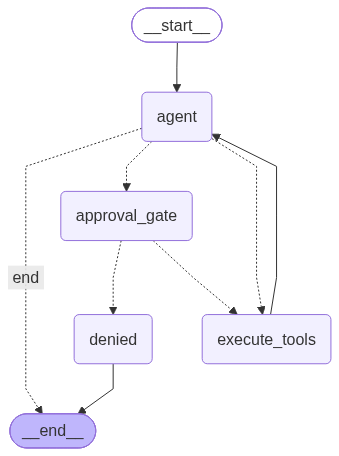

In [14]:
# Visualize the graph
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualization unavailable: {e}")
    print("Graph nodes: START -> agent -> approval_gate/execute_tools/denied -> END")

In [15]:
# Test 1: Safe tool call (no approval needed)
config1 = {"configurable": {"thread_id": "approval-test-1"}}
result = graph.invoke(
    {"messages": [("user", "Search the database for Python tutorials.")]},
    config1,
)
print("Test 1 - Safe tool:")
for msg in graph.get_state(config1).values["messages"]:
    if hasattr(msg, "type"):
        content = msg.content[:100] + "..." if len(msg.content) > 100 else msg.content
        print(f"  [{msg.type}] {content}")

Test 1 - Safe tool:
  [human] Search the database for Python tutorials.
  [ai] 
  [tool] Search results for 'Python tutorials': [data1, data2, data3]
  [ai] Based on the search results, here are some top-rated Python tutorials:

1. **Codecademy's Python Cou...


In [16]:
# Test 2: Sensitive tool call (approval required)
config2 = {"configurable": {"thread_id": "approval-test-2"}}
result = graph.invoke(
    {"messages": [("user", "Send an email to alice@example.com about the meeting.")]},
    config2,
)
print("\nTest 2 - Sensitive tool paused for approval")
print("Next node:", graph.get_state(config2).next)


Test 2 - Sensitive tool paused for approval
Next node: ('approval_gate',)


In [17]:
# Approve the tool call
result = graph.invoke(Command(resume="approve"), config2)
print("\nAfter approval:")
for msg in graph.get_state(config2).values["messages"]:
    if hasattr(msg, "type"):
        content = msg.content[:100] + "..." if len(msg.content) > 100 else msg.content
        print(f"  [{msg.type}] {content}")


After approval:
  [human] Send an email to alice@example.com about the meeting.
  [ai] 
  [tool] Email sent to alice@example.com: Meeting
  [ai] The email has been successfully sent to alice@example.com with the subject "Meeting" and a message a...


In [18]:
# Test 3: Deny a sensitive tool call
config3 = {"configurable": {"thread_id": "approval-test-3"}}
result = graph.invoke(
    {"messages": [("user", "Transfer $5000 from savings to checking.")]},
    config3,
)
print("\nTest 3 - Sensitive tool paused for approval")

# Deny the tool call
result = graph.invoke(Command(resume="deny"), config3)
print("After denial:")
for msg in graph.get_state(config3).values["messages"]:
    if hasattr(msg, "type"):
        content = msg.content[:100] + "..." if len(msg.content) > 100 else msg.content
        print(f"  [{msg.type}] {content}")


Test 3 - Sensitive tool paused for approval
After denial:
  [human] Transfer $5000 from savings to checking.
  [ai] 
  [ai] Tool call was denied by human review.


In [19]:
# Approval gate summary
print("\nApproval Gate Summary:")
print("  interrupt() pauses before sensitive tool execution")
print("  Human reviews the tool call and its arguments")
print("  Command(resume='approve') or Command(resume='deny') continues")
print("  Pattern extends to any node requiring human oversight")


Approval Gate Summary:
  interrupt() pauses before sensitive tool execution
  Human reviews the tool call and its arguments
  Command(resume='approve') or Command(resume='deny') continues
  Pattern extends to any node requiring human oversight
